In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from scipy.fft import fft2, ifft2, ifftshift

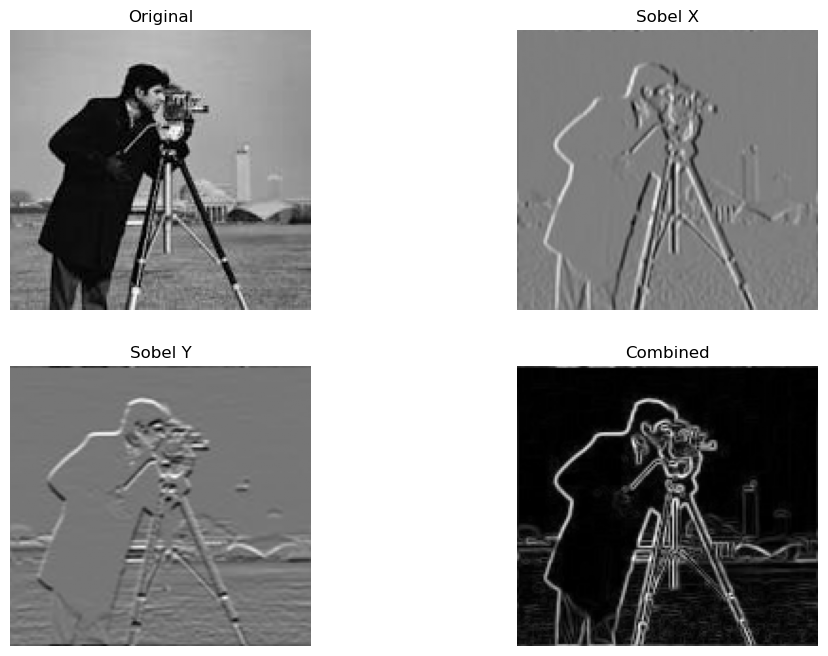

In [15]:
#Task1

image = np.array(Image.open('images/cameraman.tif').convert('L'))

sobel_x = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]])

sobel_y = np.array([[-1,-2,-1],
                    [0,0,0],
                    [1,2,1]])

def center_embed_kernel(kernel, shape):  # zero matrix same size as image
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape

    cy, cx = ph // 2, pw // 2

    padded[cy - kh//2:cy - kh//2 + kh,
           cx - kw//2:cx - kw//2 + kw] = kernel

    return fft2(ifftshift(padded))        # shift kernel to compute its FFT

F = fft2(image)

Hx = center_embed_kernel(sobel_x, image.shape) #Sobel X
Hy = center_embed_kernel(sobel_y, image.shape) #Sobel Y

Gx = F * Hx
Gy = F * Hy

gx = np.real(ifft2(Gx))
gy = np.real(ifft2(Gy))

combined = np.sqrt(gx**2 + gy**2)  # combine Sobel X and Y edges

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(gx, cmap='gray')
plt.title("Sobel X")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(gy, cmap='gray')
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(combined, cmap='gray')
plt.title("Combined")
plt.axis("off")


plt.show()